In [ ]:
from datasets import load_from_disk

ds = load_from_disk("/path/to/TDRM/outputs/datasets/rlhflow_mistral_td_prm_1413k_clamp_fixed_cosine_shaped")

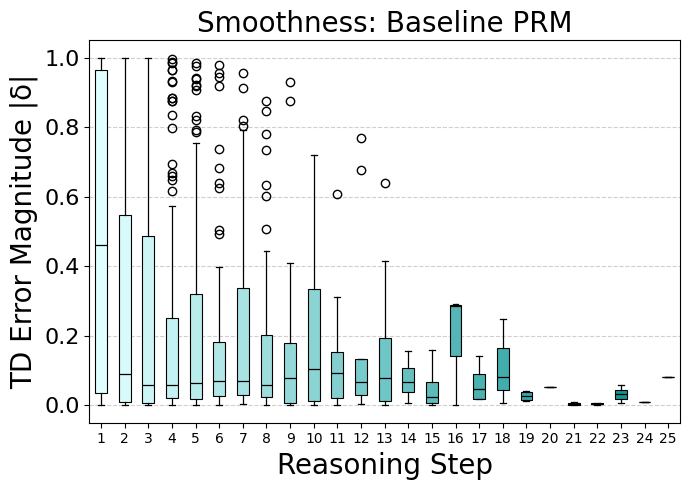

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

# Load your saved data
with open("smoothness_baseline_prm.json", "r") as f:
    data = json.load(f)

# Extract and organize
td_errors = np.array(data["td_errors"])
step_list = data["step_list"]

td_by_step = defaultdict(list)
for err, step in zip(td_errors, step_list):
    td_by_step[step].append(abs(err))

steps_sorted = sorted(td_by_step.keys())
td_error_box_data = [td_by_step[step] for step in steps_sorted]

# Define a custom cold cyan gradient
cold_cyan_cmap = mcolors.LinearSegmentedColormap.from_list(
    "cold_cyan", ["#e0ffff", "#008b8b"], N=len(steps_sorted)
)
norm = mcolors.Normalize(vmin=min(steps_sorted), vmax=max(steps_sorted))
colors = [cold_cyan_cmap(norm(step)) for step in steps_sorted]

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
box = ax.boxplot(td_error_box_data, positions=steps_sorted, patch_artist=True, showfliers=True)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.8)

for element in ['whiskers', 'caps', 'medians']:
    plt.setp(box[element], color='black', linewidth=0.9)

ax.set_xlabel("Reasoning Step", fontsize=20)
ax.set_ylabel("TD Error Magnitude |δ|", fontsize=20)
ax.set_title("Smoothness: Baseline PRM", fontsize=20)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize=16)
# plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig("../figs/smoothness_baseline_prm_boxplot.pdf", format="pdf", bbox_inches="tight")
plt.show()


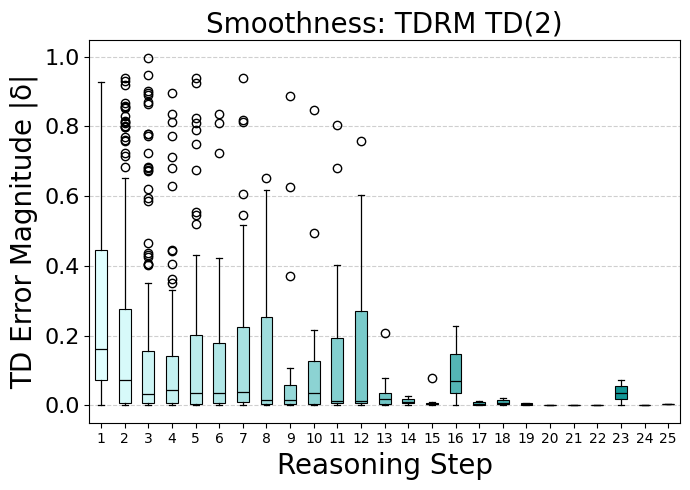

In [4]:
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

# Load your saved data
with open("smoothness_td2.json", "r") as f:
    data = json.load(f)

# Extract and organize
td_errors = np.array(data["td_errors"])
step_list = data["step_list"]

td_by_step = defaultdict(list)
for err, step in zip(td_errors, step_list):
    td_by_step[step].append(abs(err))

steps_sorted = sorted(td_by_step.keys())
td_error_box_data = [td_by_step[step] for step in steps_sorted]

# Define a custom cold cyan gradient
cold_cyan_cmap = mcolors.LinearSegmentedColormap.from_list(
    "cold_cyan", ["#e0ffff", "#008b8b"], N=len(steps_sorted)
)
norm = mcolors.Normalize(vmin=min(steps_sorted), vmax=max(steps_sorted))
colors = [cold_cyan_cmap(norm(step)) for step in steps_sorted]

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
box = ax.boxplot(td_error_box_data, positions=steps_sorted, patch_artist=True, showfliers=True)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.8)

for element in ['whiskers', 'caps', 'medians']:
    plt.setp(box[element], color='black', linewidth=0.9)

ax.set_xlabel("Reasoning Step", fontsize=20)
ax.set_ylabel("TD Error Magnitude |δ|", fontsize=20)
ax.set_title("Smoothness: TDRM TD(2)", fontsize=20)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
# plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig("../figs/smoothness_tdrm_boxplot.pdf", format="pdf", bbox_inches="tight")
plt.show()

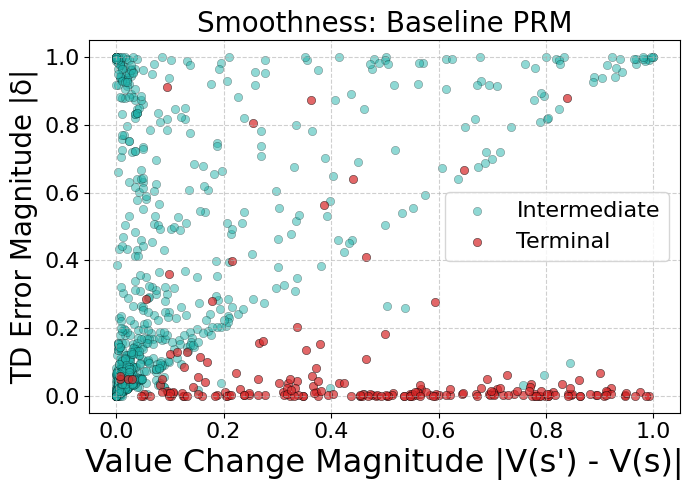

In [5]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load your saved data
with open("smoothness_baseline_prm.json", "r") as f:
    data = json.load(f)

# Extract values
v1 = np.array(data["v1_list"])
v2 = np.array(data["v2_list"])
td_errors = np.abs(np.array(data["td_errors"]))
done = np.array(data["done_list"])

value_changes = np.abs(v2 - v1)

# Split data by 'done'
non_terminal = done == 0
terminal = done == 1

# Plot
plt.figure(figsize=(7, 5))
plt.scatter(value_changes[non_terminal], td_errors[non_terminal],
            color='#20B2AA', alpha=0.5, edgecolors='k', linewidths=0.3, label='Intermediate')

plt.scatter(value_changes[terminal], td_errors[terminal],
            color='#d62728', alpha=0.7, edgecolors='k', linewidths=0.4, label='Terminal')

plt.xlabel("Value Change Magnitude |V(s') - V(s)|", fontsize=23)
plt.ylabel("TD Error Magnitude |δ|", fontsize=20)
plt.title("Smoothness: Baseline PRM", fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig("../figs/smoothness_baseline_prm_scatter.pdf", format="pdf", bbox_inches="tight")
plt.show()


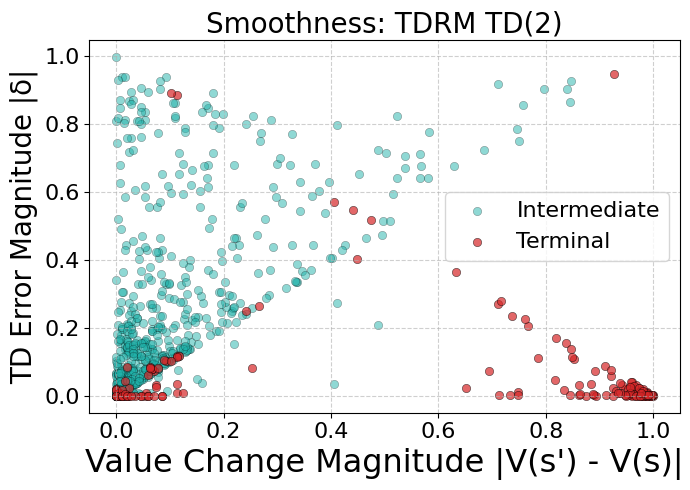

In [6]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Load your saved data
with open("smoothness_td2.json", "r") as f:
    data = json.load(f)

# Extract values
v1 = np.array(data["v1_list"])
v2 = np.array(data["v2_list"])
td_errors = np.abs(np.array(data["td_errors"]))
done = np.array(data["done_list"])

value_changes = np.abs(v2 - v1)

# Split data by 'done'
non_terminal = done == 0
terminal = done == 1

# Plot
plt.figure(figsize=(7, 5))
plt.scatter(value_changes[non_terminal], td_errors[non_terminal],
            color='#20B2AA', alpha=0.5, edgecolors='k', linewidths=0.3, label='Intermediate')

plt.scatter(value_changes[terminal], td_errors[terminal],
            color='#d62728', alpha=0.7, edgecolors='k', linewidths=0.4, label='Terminal')

plt.xlabel("Value Change Magnitude |V(s') - V(s)|", fontsize=23)
plt.ylabel("TD Error Magnitude |δ|", fontsize=20)
plt.title("Smoothness: TDRM TD(2)", fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig("../figs/smoothness_tdrm_scatter.pdf", format="pdf", bbox_inches="tight")
plt.show()


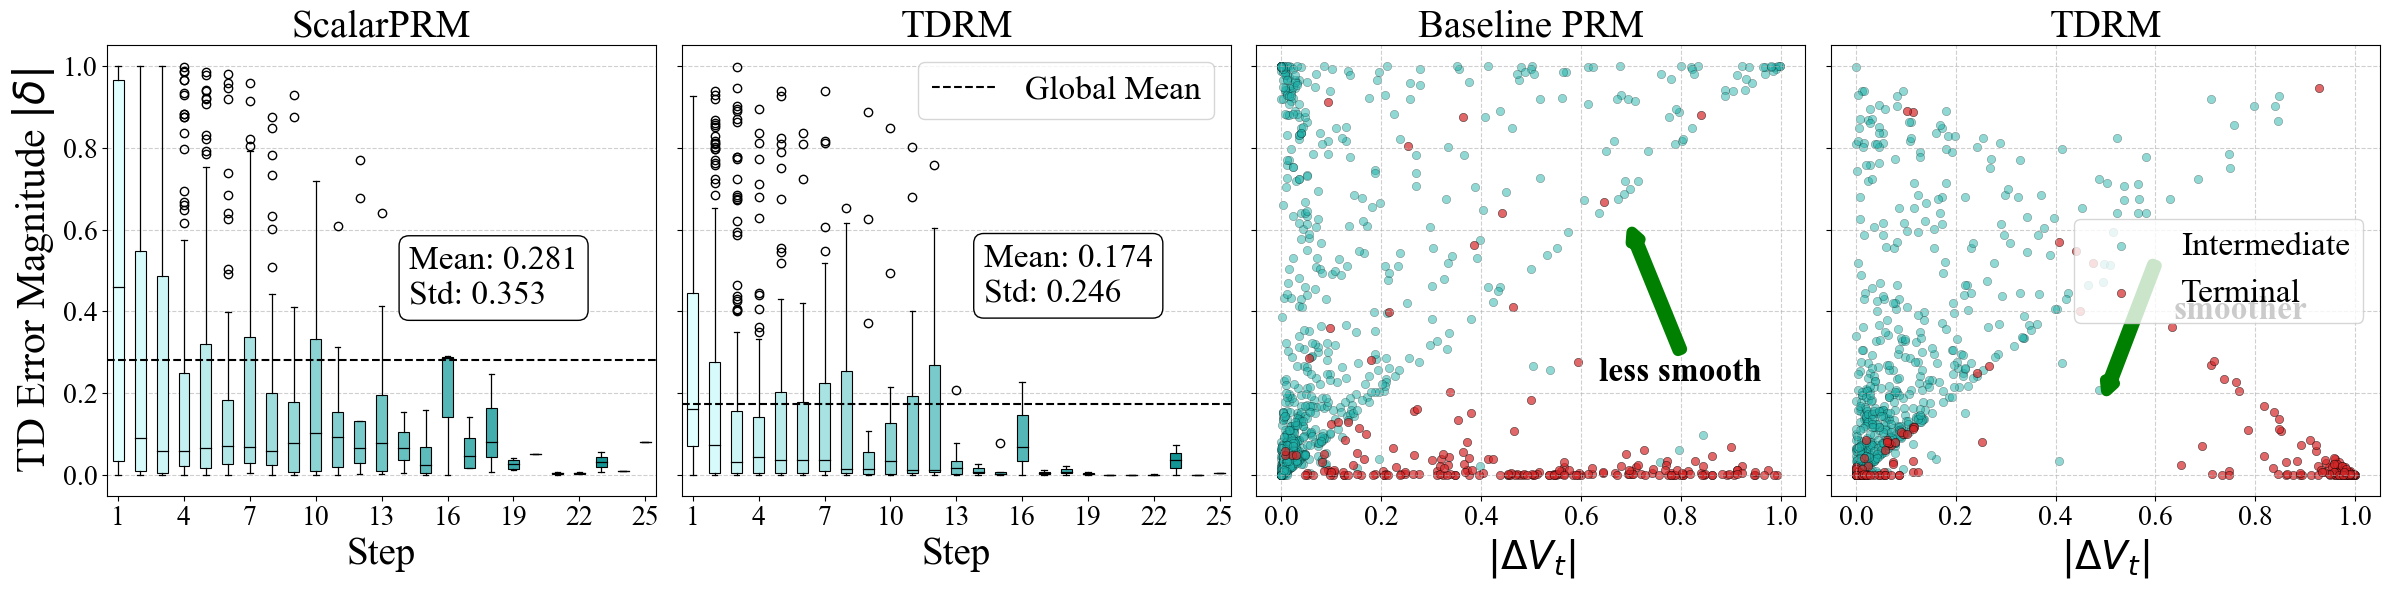

In [5]:
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import matplotlib.colors as mcolors

# Load data
def load_data(path):
    with open(path, "r") as f:
        return json.load(f)

data_prm = load_data("smoothness_baseline_prm.json")
data_td2 = load_data("smoothness_td2.json")

def prepare_box_data(data):
    td_errors = np.abs(np.array(data["td_errors"]))
    step_list = data["step_list"]
    td_by_step = defaultdict(list)
    for err, step in zip(td_errors, step_list):
        td_by_step[step].append(err)
    steps_sorted = sorted(td_by_step.keys())
    td_error_box_data = [td_by_step[step] for step in steps_sorted]
    return td_error_box_data, steps_sorted

def prepare_scatter_data(data):
    v1 = np.array(data["v1_list"])
    v2 = np.array(data["v2_list"])
    td_errors = np.abs(np.array(data["td_errors"]))
    done = np.array(data["done_list"])
    value_changes = np.abs(v2 - v1)
    return value_changes, td_errors, done

# Prepare all data
box_data_prm, steps_prm = prepare_box_data(data_prm)
box_data_td2, steps_td2 = prepare_box_data(data_td2)
vc_prm, td_prm, done_prm = prepare_scatter_data(data_prm)
vc_td2, td_td2, done_td2 = prepare_scatter_data(data_td2)

# Custom cold cyan gradient
def get_box_colors(steps_sorted):
    cmap = mcolors.LinearSegmentedColormap.from_list("cold_cyan", ["#e0ffff", "#008b8b"], N=len(steps_sorted))
    norm = mcolors.Normalize(vmin=min(steps_sorted), vmax=max(steps_sorted))
    return [cmap(norm(step)) for step in steps_sorted]

colors_prm = get_box_colors(steps_prm)
colors_td2 = get_box_colors(steps_td2)

# Plot all 4 in a single row
fig, axs = plt.subplots(1, 4, figsize=(24, 6), sharey=True)

# --- Boxplot 1: Baseline PRM ---
box1 = axs[0].boxplot(box_data_prm, positions=steps_prm, patch_artist=True, showfliers=True)
for patch, color in zip(box1['boxes'], colors_prm):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.8)
for elem in ['whiskers', 'caps', 'medians']:
    plt.setp(box1[elem], color='black', linewidth=0.9)
axs[0].set_title("ScalarPRM", fontsize=28)
axs[0].set_xlabel("Step", fontsize=28)
axs[0].set_ylabel("TD Error Magnitude $|\delta|$", fontsize=30)
axs[0].grid(True, axis='y', linestyle='--', alpha=0.6)

# Flatten and compute global mean/std across all steps
all_vals_0 = [v for step_vals in box_data_prm for v in step_vals]
mean_global_0 = np.mean(all_vals_0)
std_global_0 = np.std(all_vals_0)

# Add a single horizontal line at the global mean
axs[0].axhline(mean_global_0, linestyle='--', color='black', linewidth=1.5)

# Add callout box showing mean and std
axs[0].text(
    0.55, 0.555,
    f"Mean: {mean_global_0:.3f}\nStd: {std_global_0:.3f}",
    transform=axs[0].transAxes,
    fontsize=24,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black')
)
visible_steps_0 = steps_prm[::3]  # Show every 2nd step (adjust as needed)
axs[0].set_xticks(visible_steps_0)
axs[0].set_xticklabels(visible_steps_0, fontsize=16)




# --- Boxplot 2: TDRM TD(2) ---
box2 = axs[1].boxplot(box_data_td2, positions=steps_td2, patch_artist=True, showfliers=True)
for patch, color in zip(box2['boxes'], colors_td2):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.8)
for elem in ['whiskers', 'caps', 'medians']:
    plt.setp(box2[elem], color='black', linewidth=0.9)
axs[1].set_title("TDRM", fontsize=28)
axs[1].set_xlabel("Step", fontsize=28)
axs[1].grid(True, axis='y', linestyle='--', alpha=0.6)

all_vals_1 = [v for step_vals in box_data_td2 for v in step_vals]
mean_global_1 = np.mean(all_vals_1)
std_global_1 = np.std(all_vals_1)

axs[1].axhline(mean_global_1, linestyle='--', color='black', linewidth=1.5, label='Global Mean')

axs[1].text(
    0.55, 0.56,
    f"Mean: {mean_global_1:.3f}\nStd: {std_global_1:.3f}",
    transform=axs[1].transAxes,
    fontsize=24,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black')
)
axs[1].legend(fontsize=24)  # 🔧 Added legend

visible_steps_1 = steps_td2[::3]  # Same idea
axs[1].set_xticks(visible_steps_1)
axs[1].set_xticklabels(visible_steps_1, fontsize=23)



# --- Scatterplot 1: Baseline PRM ---
axs[2].scatter(vc_prm[done_prm == 0], td_prm[done_prm == 0],
               color='#20B2AA', alpha=0.5, edgecolors='k', linewidths=0.3, label='Intermediate')
axs[2].scatter(vc_prm[done_prm == 1], td_prm[done_prm == 1],
               color='#d62728', alpha=0.7, edgecolors='k', linewidths=0.4, label='Terminal')
axs[2].set_title("Baseline PRM", fontsize=28)
# axs[2].set_xlabel("|V(s') - V(s)|", fontsize=24)
axs[2].set_xlabel(r"$|\Delta V_{t}|$", fontsize=28)
axs[2].grid(True, linestyle='--', alpha=0.6)
# axs[2].legend(fontsize=12)  # 🔧 Added legend

axs[2].annotate(
    "",
    xy=(0.7, 0.6),                # Arrow points here (end)
    xytext=(0.8, 0.3),            # Arrow starts here
    textcoords='data',
    arrowprops=dict(
        arrowstyle='simple',
        linewidth=8,
        color='green',       # Arrow fill color
        # edgecolor='black'         # Arrow border (outline)
    ),
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

# Add a separate text label at the midpoint, sitting "on" the arrow
axs[2].text(
    0.8, 0.25, "less smooth",
    fontsize=24,
    fontweight='bold',
    ha='center',
    va='center',
    color='black'
)

# --- Scatterplot 2: TDRM TD(2) ---
axs[3].scatter(vc_td2[done_td2 == 0], td_td2[done_td2 == 0],
               color='#20B2AA', alpha=0.5, edgecolors='k', linewidths=0.3, label='Intermediate')
axs[3].scatter(vc_td2[done_td2 == 1], td_td2[done_td2 == 1],
               color='#d62728', alpha=0.7, edgecolors='k', linewidths=0.4, label='Terminal')
axs[3].set_title("TDRM", fontsize=28)
# axs[3].set_xlabel("|V(s') - V(s)|", fontsize=24)
axs[3].set_xlabel(r"$|\Delta V_{t}|$", fontsize=28)
axs[3].grid(True, linestyle='--', alpha=0.6)
axs[3].legend(fontsize=24)  # 🔧 Added legend

# Midpoint for placing the text on the arrow line
mid_x = 0.77
mid_y = 0.5 * (0.6 + 0.2)

axs[3].annotate(
    "",
    xy=(0.5, 0.2),                # Arrow points here (end)
    xytext=(0.6, 0.52),            # Arrow starts here
    # textcoords='data',
    arrowprops=dict(
        arrowstyle='simple',
        linewidth=8,
        color='green',       # Arrow fill color
        # edgecolor='black'         # Arrow border (outline)
    ),
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

# Add a separate text label at the midpoint, sitting "on" the arrow
axs[3].text(
    mid_x, mid_y, "smoother",
    fontsize=24,
    fontweight='bold',
    ha='center',
    va='center',
    color='black'
)



# Common formatting
for ax in axs:
    ax.tick_params(axis='both', labelsize=20)

fig.tight_layout()
plt.savefig("../figs/smoothness_comparison.pdf", format="pdf", bbox_inches="tight")
plt.show()


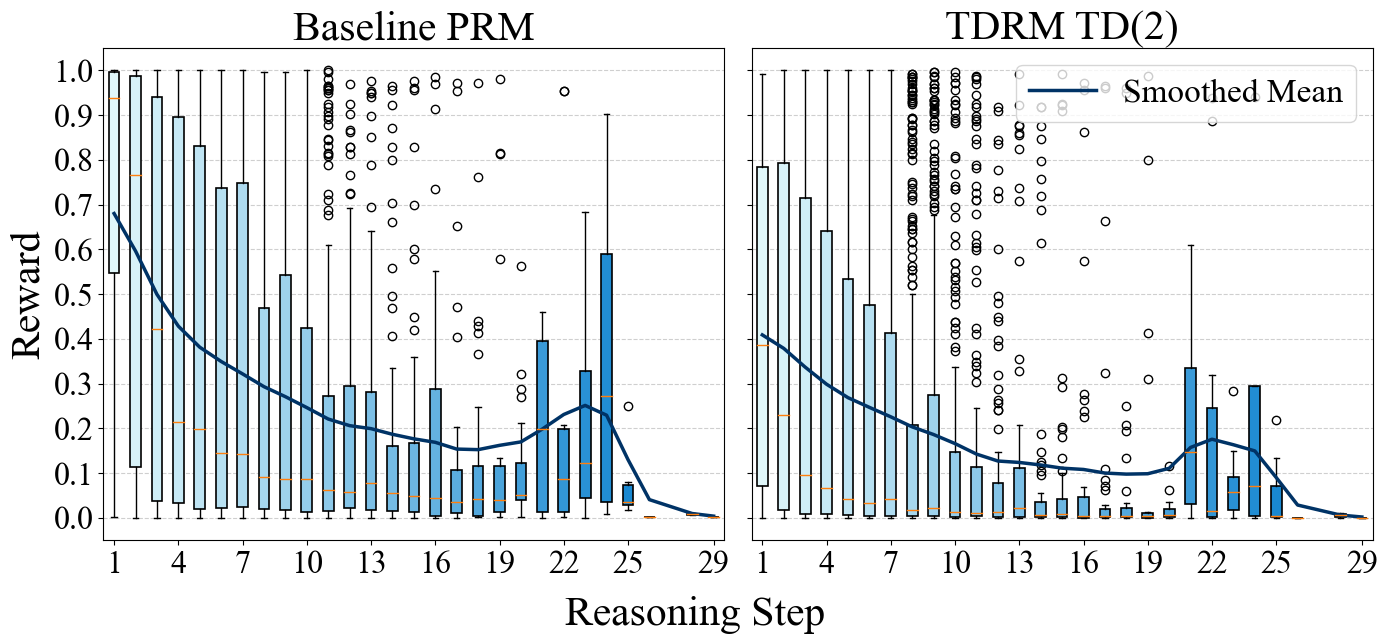

In [21]:
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter1d

# Load and group reward data by reasoning step
def load_reward_by_step(path):
    with open(path, "r") as f:
        data = json.load(f)
    reward_list = data["v1_list"]
    step_list = data["step_list"]
    rewards_by_step = defaultdict(list)
    for reward, step in zip(reward_list, step_list):
        rewards_by_step[step].append(reward)
    steps_sorted = sorted(rewards_by_step.keys())
    reward_box_data = [rewards_by_step[step] for step in steps_sorted]
    return reward_box_data, steps_sorted

# Load data
reward_data_prm, steps_prm = load_reward_by_step("reward_baseline_prm.json")
reward_data_td2, steps_td2 = load_reward_by_step("reward_td2.json")

# Gradient blue colors
def get_gradient_blue(n):
    cmap = mcolors.LinearSegmentedColormap.from_list("blue_gradient", ["#e0f7fa", "#007acc"], N=n)
    return [cmap(i / max(n - 1, 1)) for i in range(n)]

colors_prm = get_gradient_blue(len(reward_data_prm))
colors_td2 = get_gradient_blue(len(reward_data_td2))

# Compute per-step means
mean_prm = np.array([np.mean(x) for x in reward_data_prm])
mean_td2 = np.array([np.mean(x) for x in reward_data_td2])

# Smooth the mean curves using Gaussian smoothing (on discrete steps)
mean_prm_smooth = gaussian_filter1d(mean_prm, sigma=1)
mean_td2_smooth = gaussian_filter1d(mean_td2, sigma=1)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Baseline PRM ---
box1 = axs[0].boxplot(reward_data_prm, positions=steps_prm, patch_artist=True, showfliers=True)
for patch, color in zip(box1['boxes'], colors_prm):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.2)
axs[0].plot(steps_prm, mean_prm_smooth, color='#003366', linewidth=2.5, label='Smoothed Mean')
axs[0].set_title("Baseline PRM", fontsize=30)
# axs[0].set_xlabel("Reasoning Step", fontsize=18)
axs[0].set_ylabel("Reward", fontsize=30)
# axs[0].tick_params(axis='both', labelsize=14)
axs[0].grid(True, axis='y', linestyle='--', alpha=0.6)
# axs[0].legend(fontsize=14)

# axs[0].set_yticks(ticks=np.arange(0.0, 1.01, 0.1), fontsize=28)

visible_steps_1 = steps_td2[::3]  # Same idea
axs[0].set_xticks(visible_steps_1)
axs[0].set_xticklabels(visible_steps_1, fontsize=23)

# --- TDRM TD(2) ---
box2 = axs[1].boxplot(reward_data_td2, positions=steps_td2, patch_artist=True, showfliers=True)
for patch, color in zip(box2['boxes'], colors_td2):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.2)
axs[1].plot(steps_td2, mean_td2_smooth, color='#003366', linewidth=2.5, label='Smoothed Mean')
axs[1].set_title("TDRM TD(2)", fontsize=30)
# axs[1].set_xlabel("Reasoning Step", fontsize=18)
# axs[1].tick_params(axis='both', labelsize=14)
axs[1].grid(True, axis='y', linestyle='--', alpha=0.6)
axs[1].legend(fontsize=24, loc='upper right')

visible_steps_1 = steps_td2[::3]  # Same idea
axs[1].set_xticks(visible_steps_1)
axs[1].set_xticklabels(visible_steps_1, fontsize=23)

yticks = np.arange(0.0, 1.01, 0.1)  # or whatever range you want

for ax in axs:
    ax.set_yticks(yticks)
    ax.tick_params(axis='y', labelsize=23)

fig.text(0.5, -0.05, "Reasoning Step", ha='center', fontsize=30)
plt.tight_layout()
plt.savefig("../figs/reward_comparison.pdf", format="pdf", bbox_inches="tight")
plt.show()


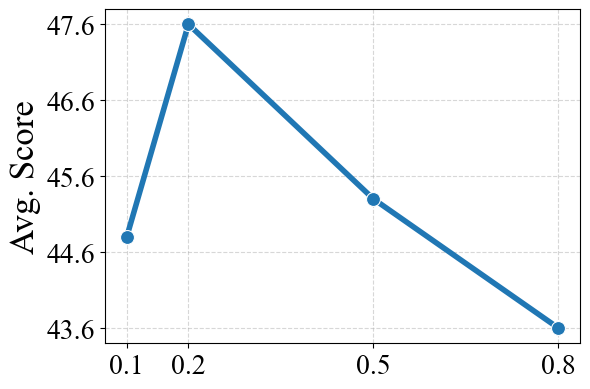

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data
data = {
    'a': [0.1, 0.2, 0.5, 0.8],
    'Avg. Score': [44.8, 47.6, 45.3, 43.6]

}

# plt.rcParams['text.usetex'] = True


# Create DataFrame and ensure numeric x-axis
df = pd.DataFrame(data)
df['a'] = df['a'].astype(float)

# Plot
plt.figure(figsize=(6, 4))
ymin, ymax = df['Avg. Score'].min(), df['Avg. Score'].max()
plt.yticks(np.linspace(ymin, ymax, 5))  # 3 evenly spaced ticks
sns.lineplot(data=df, x='a', color="#2077B4", y='Avg. Score', marker='o', linewidth=4, markersize=10)
plt.rc('font', family='Times New Roman')
# Styling
# plt.title("Performance using Different $a$", fontsize=28)
plt.xlabel(r"", fontsize=25)
plt.ylabel("Avg. Score", fontsize=25)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(df['a'])  # Use actual x values as tick marks

plt.tight_layout()
plt.savefig("../figs/avg_score_vs_a.pdf", format="pdf", bbox_inches="tight")
plt.show()


Found cached dataset parquet (/Users/henrycai/.cache/huggingface/datasets/RLHFlow___parquet/RLHFlow--Mistral-PRM-Data-50266c5ec774aa2a/0.0.0/2a3b91fbd88a2c90d1dbbb32b460cf621d31bd5b05b934492fdef7d8d6f236ec)
100%|██████████| 1/1 [00:00<00:00, 10.89it/s]


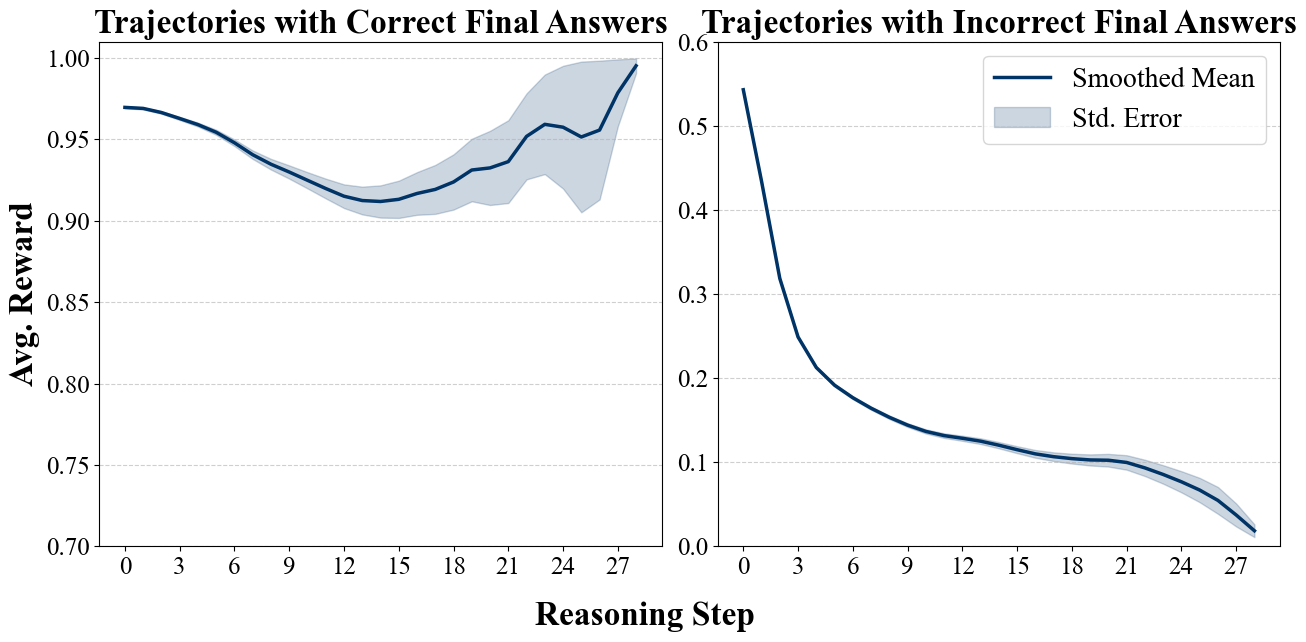

In [6]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter1d
from datasets import load_dataset

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Times New Roman'

# -------- Step 1: Group trajectories by final score -------- #
def split_by_terminal_score(dataset):
    group_1 = []  # terminal '+' => final score = 1
    group_0 = []  # otherwise => final score = 0

    for item in dataset:
        convo_data = item["conversations"][:1000]
        conversation = convo_data

        if not isinstance(conversation, list) or len(conversation) < 2:
            continue

        # Last assistant turn (assumed interleaved user/assistant)
        for i in range(len(conversation) - 1, -1, -1):
            if conversation[i]["role"] == "assistant":
                final_score = 1 if conversation[i]["content"].strip() == "+" else 0
                break
        else:
            continue  # no assistant turn found

        if final_score == 1:
            group_1.append(item)
        else:
            group_0.append(item)

    return group_1, group_0

# -------- Step 2: Extract binary rewards by step -------- #
def extract_binary_rewards(dataset):
    rewards_by_step = defaultdict(list)
    for item in dataset:
        conversation = item["conversations"]
        step = 0
        for i in range(0, len(conversation) - 1, 2):
            user_msg = conversation[i]
            assistant_msg = conversation[i + 1]

            if user_msg["role"] != "user" or assistant_msg["role"] != "assistant":
                continue

            score = 1 if assistant_msg["content"].strip() == "+" else 0
            rewards_by_step[step].append(score)
            step += 1

    steps_sorted = sorted(rewards_by_step)
    reward_box_data = [rewards_by_step[step] for step in steps_sorted]
    return reward_box_data, steps_sorted

# -------- Step 3: Plotting function -------- #
def get_gradient_blue(n):
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("blue_gradient", ["#e0f7fa", "#007acc"], N=n)
    return [cmap(i / max(n - 1, 1)) for i in range(n)]

def plot_groups(group_1, group_0):
    reward_data_1, steps_1 = extract_binary_rewards(group_1)
    reward_data_0, steps_0 = extract_binary_rewards(group_0)

    # Mean and std error
    mean_1 = np.array([np.mean(x) for x in reward_data_1])
    mean_0 = np.array([np.mean(x) for x in reward_data_0])
    std_1 = np.array([np.std(x) / np.sqrt(len(x)) for x in reward_data_1])  # Standard Error
    std_0 = np.array([np.std(x) / np.sqrt(len(x)) for x in reward_data_0])  # Standard Error

    # Smooth mean and std error
    mean_1_smooth = gaussian_filter1d(mean_1, sigma=1)
    mean_0_smooth = gaussian_filter1d(mean_0, sigma=1)
    std_1_smooth = gaussian_filter1d(std_1, sigma=1)
    std_0_smooth = gaussian_filter1d(std_0, sigma=1)

    fig, axs = plt.subplots(1, 2, figsize=(13, 6))  # No shared y-axis

    # --- Group with terminal score 1 ---
    axs[0].plot(steps_1, mean_1_smooth, color='#003366', linewidth=2.5, label='Smoothed Mean')
    axs[0].fill_between(
        steps_1,
        mean_1_smooth - std_1_smooth,
        mean_1_smooth + std_1_smooth,
        color='#003366',
        alpha=0.2,
        label='Std. Error'
    )
    axs[0].set_title("Trajectories with Correct Final Answers", fontsize=24, fontweight='bold')
    axs[0].set_ylabel("Avg. Reward", fontsize=24, fontweight='bold')
    axs[0].set_xticks(steps_1[::3])
    axs[0].set_xticklabels(steps_1[::3], fontsize=18)
    axs[0].tick_params(axis='y', labelsize=18)
    axs[0].grid(True, axis='y', linestyle='--', alpha=0.6)
    axs[0].set_ylim(0.7, 1.01)
    axs[0].set_yticks(np.arange(0.7, 1.01, 0.05))

    # --- Group with terminal score 0 ---
    axs[1].plot(steps_0, mean_0_smooth, color='#003366', linewidth=2.5, label='Smoothed Mean')
    axs[1].fill_between(
        steps_0,
        mean_0_smooth - std_0_smooth,
        mean_0_smooth + std_0_smooth,
        color='#003366',
        alpha=0.2,
        label='Std. Error'
    )
    axs[1].set_title("Trajectories with Incorrect Final Answers", fontsize=24, fontweight='bold')
    axs[1].set_xticks(steps_0[::3])
    axs[1].set_xticklabels(steps_0[::3], fontsize=18)
    axs[1].tick_params(axis='y', labelsize=18)
    axs[1].grid(True, axis='y', linestyle='--', alpha=0.6)
    axs[1].set_ylim(0.0, 0.6)
    axs[1].set_yticks(np.arange(0.0, 0.7, 0.1))

    axs[1].legend(fontsize=20)
    fig.text(0.5, -0.05, "Reasoning Step", ha='center', fontsize=24, fontweight='bold')
    plt.tight_layout()
    plt.savefig("grouped_binary_reward_with_errorbar.pdf", format="pdf", bbox_inches="tight")
    plt.show()

# -------- Step 4: Load and run -------- #
dataset = load_dataset("RLHFlow/Mistral-PRM-Data")["train"]
group_1, group_0 = split_by_terminal_score(dataset)
plot_groups(group_1, group_0)
